# Анализ исходных данных, ручное обучение моделей и подготовка отчетов

Практический notebook для manual workflow в ml-server. Он дополняет Stage 0-6 documentation и позволяет:

- проверить качество исходных данных до обучения;
- провести exploratory data analysis;
- вручную обучить несколько кандидатов;
- сравнить алгоритмы по общей схеме;
- собрать human-readable report bundle.

> Важно: notebook не зависит от не реализованного `POST /train` и предназначен для offline/manual workflow.

## 0. Объем работ и ожидаемые результаты

На выходе notebook должен дать:

- summary по данным;
- metrics по baseline и model candidates;
- recommendation по выбору алгоритма;
- optional export файлов для дальнейшего review.

Связанные документы:

- Stage 0: readiness и pre-flight checks;
- Stage 4: manual training patterns;
- Stage 5: canonical metrics and artifact layout.

## 1. Setup — выбор модели

Загрузка batch-списка моделей, выбор конкретной строки и определение базовых переменных сессии (`SELECTED_OBJECT_REF`, `SELECTED_OUTPUT_RANGE`, пути к данным).

In [1]:
# ── Setup: выбор модели из batch_summary.json ──────────────────────────────
import hashlib
import io
import json
import math
import shutil
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import xgboost as xgb
    xgboost_available = True
except ImportError:
    xgb = None
    xgboost_available = False


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'ml-server').exists() and (candidate / 'local' / 'models').exists():
            return candidate
    return start


def _sanitize_slug(value: str) -> str:
    return str(value).replace('/', '_').replace(' ', '_').replace('@', '').strip('_')


PROJECT_ROOT = Path('/Users/rustamkrikbayev/Documents/projects/forecast/local/models/')
BATCH_OUTPUT_ROOT = PROJECT_ROOT
BATCH_SUMMARY = BATCH_OUTPUT_ROOT / 'batch_summary.json'

# Read batch_summary.json as the single source of truth
if not BATCH_SUMMARY.exists():
    raise FileNotFoundError(f'Cannot proceed: batch_summary.json not found at {BATCH_SUMMARY}')

_summary_data = json.loads(BATCH_SUMMARY.read_text(encoding='utf-8'))

# Filter entries with status='ok' and extract training-critical fields
_ready_list = []
for _s in _summary_data:
    if str(_s.get('status', '')).strip().lower() != 'ok':
        continue

    _ready_list.append({
        'object_ref': str(_s.get('object_ref', '')),
        'output_range': int(_s.get('output_range', 24)),
        'train_snapshot_path': str(_s.get('train_snapshot_path', '')),
        'status': 'ok',
    })

if not _ready_list:
    raise RuntimeError('No models with status=ok in batch_summary.json. Run MODEL_DATA_COLLECTION first.')

_ready = pd.DataFrame(_ready_list)

# Filter: keep only entries with existing parquet files
_ready['train_path_obj'] = _ready['train_snapshot_path'].apply(Path)
_ready['parquet_exists'] = _ready['train_path_obj'].apply(lambda p: p.exists())
_ready = _ready[_ready['parquet_exists']].reset_index(drop=True)

if _ready.empty:
    missing_list = ', '.join([str(r['train_snapshot_path']) for r in _ready_list])
    raise RuntimeError(f'No valid training snapshots found. Missing: {missing_list}')

# Compatibility alias for downstream cells that still reference _train_parquet
_ready['_train_parquet'] = _ready['train_snapshot_path']

print(f'Models in batch_summary.json: {len(_summary_data)}')
print(f'Models with status=ok: {len(_ready_list)}')
print(f'Models with valid parquet: {len(_ready)}')
print(f'xgboost_available: {xgboost_available}')
print()
display(_ready[['object_ref', 'output_range', 'status']].to_string(index=False))

# ── Select model by row index (default: first) ─────────────────────────────
SELECTED_ROW_INDEX = 1

_row = _ready.iloc[SELECTED_ROW_INDEX]
SELECTED_OBJECT_REF = str(_row['object_ref'])
SELECTED_TRAIN_PATH = Path(str(_row['train_snapshot_path']))
SELECTED_OUTPUT_RANGE = int(_row['output_range'])

print(f'\nSelected [{SELECTED_ROW_INDEX}]: {SELECTED_OBJECT_REF}')
print(f'  train_snapshot: {SELECTED_TRAIN_PATH}')
print(f'  exists: {SELECTED_TRAIN_PATH.exists()}')
print(f'  output_range: {SELECTED_OUTPUT_RANGE}')

Models in batch_summary.json: 3
Models with status=ok: 3
Models with valid parquet: 3
xgboost_available: True



'                                                           object_ref  output_range status\n                   /root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_watt            36     ok\n/root/FP/PROJECT/AKMOLA/@regions/North Kazakhstan/load/@models/P_watt            36     ok\n       /root/FP/PROJECT/AKMOLA/@regions/Kokshetau/load/@models/P_watt            36     ok'


Selected [1]: /root/FP/PROJECT/AKMOLA/@regions/North Kazakhstan/load/@models/P_watt
  train_snapshot: /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt/datasets/train_snapshot.parquet
  exists: True
  output_range: 36


## 2. Конфигурация

Определение `TrainingNotebookConfig` — датакласс с параметрами обучения, путями и гиперпараметрами. Создается экземпляр `cfg`.

In [2]:
from dataclasses import asdict, dataclass, field
from typing import Any


@dataclass
class TrainingNotebookConfig:
    dataset_path: Path
    dataset_format: str = 'parquet'
    timestamp_column: str = 'timestamp'
    target_column: str = 'value'
    freq: str = 'H'
    train_ratio: float = 0.7
    validation_ratio: float = 0.15
    forecast_horizon: int = 24
    create_xgb_features: bool = True
    active_candidates: tuple[str, ...] = ('naive_last', 'prophet', 'xgboost')
    xgb_params: dict[str, Any] | None = None
    prophet_params: dict[str, Any] | None = None

    # Unified model storage root (single structure for offline train + runtime cache).
    model_store_root: Path | None = None
    bundle_output_dir: Path | None = None

    # MLflow workflow settings.
    mlflow_enabled: bool = False
    mlflow_tracking_uri: str | None = None
    mlflow_run_name_prefix: str = 'manual_workflow'
    object_reference: str = '/MANUAL/NOTEBOOK/OBJECT'

    # Derive MLflow names and local layout from object_reference/model_id.
    mlflow_experiment_name: str = field(default='', init=False)
    mlflow_model_registry_name: str = field(default='', init=False)
    model_id: str = field(default='', init=False)
    model_home_dir: Path = field(default=Path('.'), init=False)
    training_artifacts_dir: Path = field(default=Path('.'), init=False)
    training_reports_dir: Path = field(default=Path('.'), init=False)
    runtime_cache_dir: Path = field(default=Path('.'), init=False)

    # Dataset snapshot settings.
    dataset_snapshot_enabled: bool = True
    feature_schema_version: str = '1'

    def __post_init__(self) -> None:
        repo_root = Path(PROJECT_ROOT)
        if self.model_store_root is None:
            self.model_store_root = repo_root / 'local' / 'models'

        self.model_id = _sanitize_slug(str(self.object_reference)) + f'_h{self.forecast_horizon}'
        self.mlflow_experiment_name = str(self.object_reference)
        self.mlflow_model_registry_name = self.model_id + '_model'

        self.model_home_dir = Path(self.model_store_root) / self.model_id
        self.training_artifacts_dir = self.model_home_dir / 'training'
        self.training_reports_dir = self.training_artifacts_dir / 'reports'
        self.runtime_cache_dir = self.model_home_dir / 'runtime_cache'

        if self.bundle_output_dir is None:
            self.bundle_output_dir = self.training_artifacts_dir / 'bundle_export'

        for path in (
            self.model_home_dir,
            self.training_artifacts_dir,
            self.training_reports_dir,
            self.runtime_cache_dir,
            Path(self.bundle_output_dir),
        ):
            path.mkdir(parents=True, exist_ok=True)


cfg = TrainingNotebookConfig(
    # ── данные из batch collection (заполняются ячейкой выбора модели выше) ────
    dataset_path=SELECTED_TRAIN_PATH,
    dataset_format='parquet',
    timestamp_column='ds',    # batch script пишет колонки ds / y
    target_column='y',
    forecast_horizon=SELECTED_OUTPUT_RANGE,
    object_reference=SELECTED_OBJECT_REF,
    model_store_root=_find_repo_root(Path(PROJECT_ROOT)) / 'local' / 'models',
    mlflow_enabled=True,
    mlflow_tracking_uri='http://127.0.0.1:5050',
    mlflow_run_name_prefix='manual_training',
    xgb_params={
        'objective': 'reg:squarederror',
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42,
    },
    prophet_params={
        'seasonality_mode': 'multiplicative',
        'changepoint_prior_scale': 0.05,
        'weekly_seasonality': True,
        'daily_seasonality': True,
    },
)

print(f'experiment name      : {cfg.mlflow_experiment_name}')
print(f'registry model_id    : {cfg.mlflow_model_registry_name}')
print(f'model_store_root     : {cfg.model_store_root}')
print(f'model_home_dir       : {cfg.model_home_dir}')
print(f'training_reports_dir : {cfg.training_reports_dir}')
print(f'runtime_cache_dir    : {cfg.runtime_cache_dir}')
asdict(cfg)

experiment name      : /root/FP/PROJECT/AKMOLA/@regions/North Kazakhstan/load/@models/P_watt
registry model_id    : root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36_model
model_store_root     : /Users/rustamkrikbayev/Documents/projects/forecast/local/models
model_home_dir       : /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36
training_reports_dir : /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/reports
runtime_cache_dir    : /Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/runtime_cache


{'dataset_path': PosixPath('/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt/datasets/train_snapshot.parquet'),
 'dataset_format': 'parquet',
 'timestamp_column': 'ds',
 'target_column': 'y',
 'freq': 'H',
 'train_ratio': 0.7,
 'validation_ratio': 0.15,
 'forecast_horizon': 36,
 'create_xgb_features': True,
 'active_candidates': ('naive_last', 'prophet', 'xgboost'),
 'xgb_params': {'objective': 'reg:squarederror',
  'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.05,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'random_state': 42},
 'prophet_params': {'seasonality_mode': 'multiplicative',
  'changepoint_prior_scale': 0.05,
  'weekly_seasonality': True,
  'daily_seasonality': True},
 'model_store_root': PosixPath('/Users/rustamkrikbayev/Documents/projects/forecast/local/models'),
 'bundle_output_dir': PosixPath('/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT

## 3. Загрузка данных

Читаем CSV/parquet по пути `cfg.dataset_path`, нормализуем колонки в `ds` и `y`, получаем `raw_df`.

In [3]:
def load_dataset(config: TrainingNotebookConfig) -> pd.DataFrame:
    path = Path(config.dataset_path)
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found: {path}')

    dataset_format = str(config.dataset_format).lower()
    if dataset_format == 'csv':
        df = pd.read_csv(path)
    elif dataset_format == 'parquet':
        df = pd.read_parquet(path)
    else:
        raise ValueError(f'Unsupported dataset_format: {config.dataset_format}')

    if config.timestamp_column not in df.columns or config.target_column not in df.columns:
        raise KeyError('timestamp_column/target_column are missing in dataset')

    df = df[[config.timestamp_column, config.target_column]].copy()
    df[config.timestamp_column] = pd.to_datetime(df[config.timestamp_column], utc=True, errors='coerce')
    df = df.rename(columns={config.timestamp_column: 'ds', config.target_column: 'y'})
    df = df.sort_values('ds').reset_index(drop=True)
    return df

raw_df = load_dataset(cfg) if cfg.dataset_path.exists() else pd.DataFrame(columns=['ds', 'y'])
raw_df.head()

,ds,y
0,2026-04-22 07:00:00+00:00,185.026272
1,2026-04-22 08:00:00+00:00,176.587626
2,2026-04-22 09:00:00+00:00,178.623374
3,2026-04-22 10:00:00+00:00,172.570221
4,2026-04-22 11:00:00+00:00,152.996077


## 4. Визуализация исходных данных

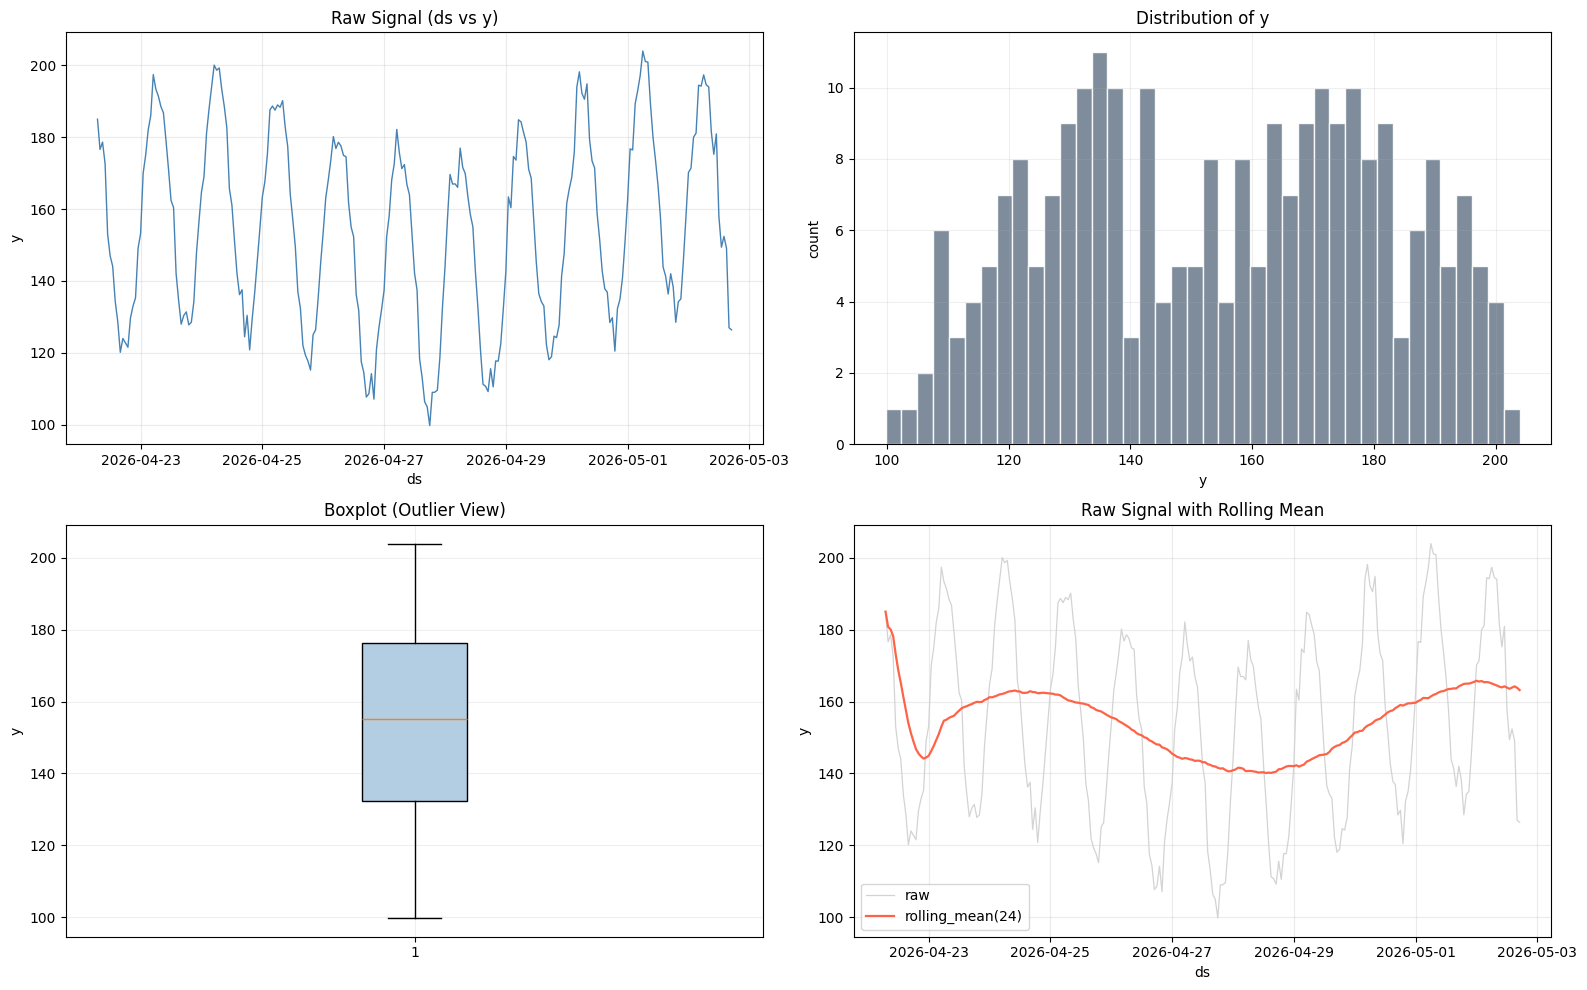

In [4]:
if raw_df.empty:
    print('Dataset is empty: nothing to visualize.')
else:
    _viz = raw_df[['ds', 'y']].copy()
    _viz['ds'] = pd.to_datetime(_viz['ds'], errors='coerce')
    _viz = _viz.dropna(subset=['ds', 'y']).sort_values('ds').reset_index(drop=True)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1) Raw signal
    axes[0, 0].plot(_viz['ds'], _viz['y'], color='steelblue', linewidth=1.0)
    axes[0, 0].set_title('Raw Signal (ds vs y)')
    axes[0, 0].set_xlabel('ds')
    axes[0, 0].set_ylabel('y')
    axes[0, 0].grid(alpha=0.25)

    # 2) Value distribution
    axes[0, 1].hist(_viz['y'].to_numpy(dtype=float), bins=40, color='slategray', edgecolor='white', alpha=0.9)
    axes[0, 1].set_title('Distribution of y')
    axes[0, 1].set_xlabel('y')
    axes[0, 1].set_ylabel('count')
    axes[0, 1].grid(alpha=0.2)

    # 3) Boxplot for outliers
    axes[1, 0].boxplot(_viz['y'].to_numpy(dtype=float), vert=True, patch_artist=True, boxprops={'facecolor': '#b3cde3'})
    axes[1, 0].set_title('Boxplot (Outlier View)')
    axes[1, 0].set_ylabel('y')
    axes[1, 0].grid(alpha=0.2)

    # 4) Raw + rolling mean
    _window = 24 if len(_viz) >= 24 else max(3, len(_viz) // 5)
    _window = max(2, _window)
    _roll = _viz['y'].rolling(window=_window, min_periods=1).mean()
    axes[1, 1].plot(_viz['ds'], _viz['y'], color='lightgray', linewidth=0.9, label='raw')
    axes[1, 1].plot(_viz['ds'], _roll, color='tomato', linewidth=1.6, label=f'rolling_mean({_window})')
    axes[1, 1].set_title('Raw Signal with Rolling Mean')
    axes[1, 1].set_xlabel('ds')
    axes[1, 1].set_ylabel('y')
    axes[1, 1].grid(alpha=0.25)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


## 5. Расчет метрик

In [6]:
def run_data_quality_checks(df: pd.DataFrame, config: TrainingNotebookConfig) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame([
            {'check': 'dataset_not_empty', 'status': 'fail', 'value': 0, 'notes': 'Dataset is empty'}
        ])

    time_delta = df['ds'].diff().dropna()
    expected_step = pd.to_timedelta(config.freq.lower()) if config.freq.upper() != 'H' else pd.Timedelta(hours=1)
    duplicate_count = int(df['ds'].duplicated().sum())
    null_ratio = float(df['y'].isna().mean())
    zero_ratio = float((df['y'].fillna(0) == 0).mean())
    gap_count = int((time_delta > expected_step).sum()) if not time_delta.empty else 0
    value_series = df['y'].dropna()
    sample_size = int(len(df))

    checks = [
        {'check': 'dataset_not_empty', 'status': 'ok' if sample_size > 0 else 'fail', 'value': sample_size, 'notes': 'Rows in dataset'},
        {'check': 'timestamp_duplicates', 'status': 'ok' if duplicate_count == 0 else 'warn', 'value': duplicate_count, 'notes': 'Duplicated timestamps'},
        {'check': 'target_null_ratio', 'status': 'ok' if null_ratio <= 0.05 else 'warn', 'value': round(null_ratio, 4), 'notes': 'Null share in target column'},
        {'check': 'target_zero_ratio', 'status': 'ok' if zero_ratio < 0.95 else 'warn', 'value': round(zero_ratio, 4), 'notes': 'Share of zero values'},
        {'check': 'time_gaps', 'status': 'ok' if gap_count == 0 else 'warn', 'value': gap_count, 'notes': 'Detected gaps larger than expected frequency'},
        {'check': 'target_variance', 'status': 'ok' if value_series.nunique() > 1 else 'fail', 'value': int(value_series.nunique()), 'notes': 'Unique non-null values'},
        {'check': 'min_sample_size', 'status': 'ok' if sample_size >= max(7 * config.forecast_horizon, 200) else 'warn', 'value': sample_size, 'notes': 'Heuristic minimum for manual training'},
    ]
    return pd.DataFrame(checks)


quality_df = run_data_quality_checks(raw_df, cfg)
quality_df

,check,status,value,notes
0,dataset_not_empty,ok,251.0,Rows in dataset
1,timestamp_duplicates,ok,0.0,Duplicated timestamps
2,target_null_ratio,ok,0.0,Null share in target column
3,target_zero_ratio,ok,0.0,Share of zero values
4,time_gaps,ok,0.0,Detected gaps larger than expected frequency
5,target_variance,ok,251.0,Unique non-null values
6,min_sample_size,warn,251.0,Heuristic minimum for manual training


## 6. Профиль данных и базовая статистика

,rows,start,end,mean,median,std,min,max,p05,p95
0,251,2026-04-22 07:00:00+00:00,2026-05-02 17:00:00+00:00,154.3372,155.0874,26.3412,99.7791,203.964,112.1987,194.3324


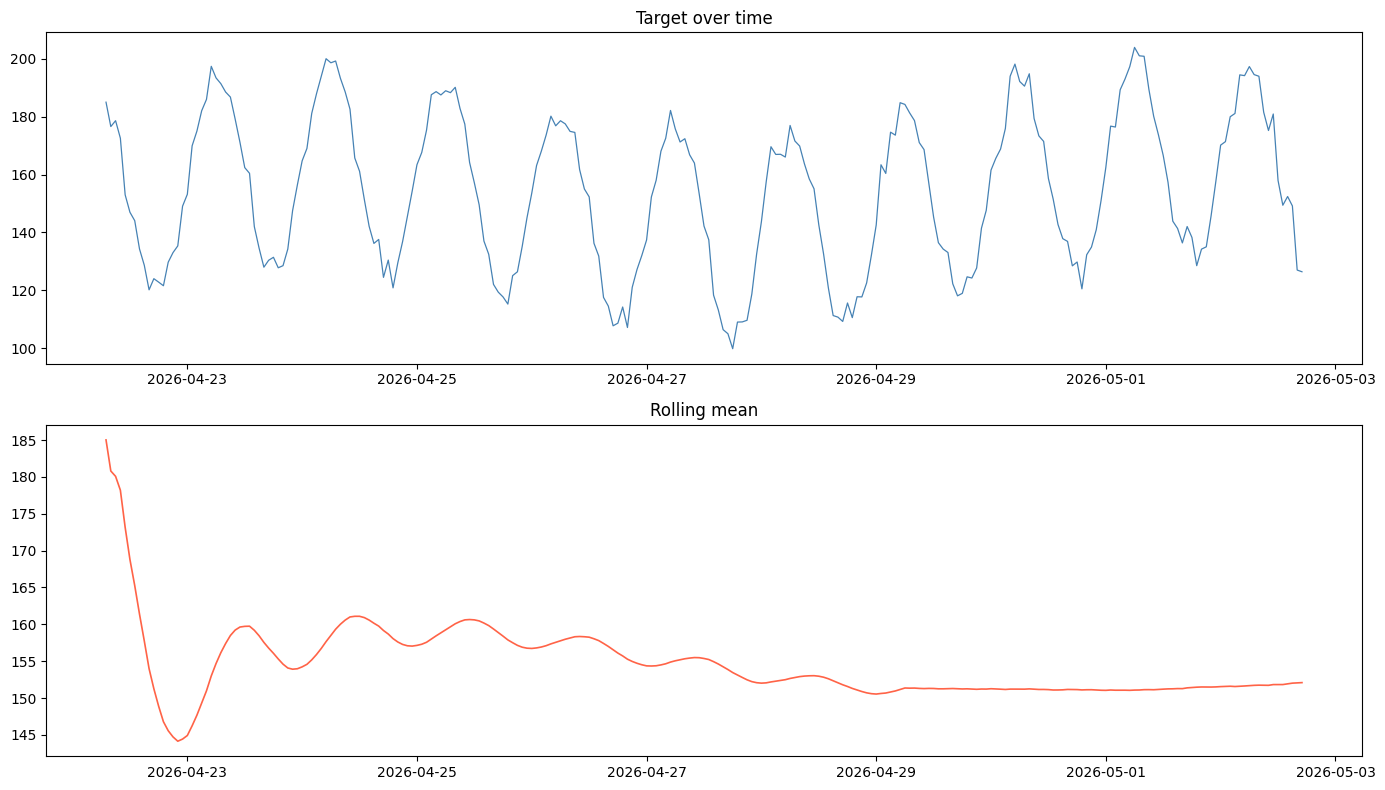

In [7]:
def describe_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    series = df['y'].dropna()
    summary = {
        'rows': len(df),
        'start': df['ds'].min(),
        'end': df['ds'].max(),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'min': series.min(),
        'max': series.max(),
        'p05': series.quantile(0.05),
        'p95': series.quantile(0.95),
    }
    return pd.DataFrame([summary]).round(4)


profile_df = describe_dataset(raw_df)
display(profile_df)

if not raw_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    axes[0].plot(raw_df['ds'], raw_df['y'], color='steelblue', linewidth=0.9)
    axes[0].set_title('Target over time')

    rolling = raw_df['y'].rolling(window=min(24 * 7, max(3, len(raw_df))), min_periods=1).mean()
    axes[1].plot(raw_df['ds'], rolling, color='tomato', linewidth=1.2)
    axes[1].set_title('Rolling mean')

    plt.tight_layout()
    plt.show()

## 7. Разбивка на train / val / test

Делим `raw_df` по пропорциям `cfg.train_ratio` / `cfg.validation_ratio` / остаток → `train_df`, `val_df`, `test_df`.

In [9]:
# Split raw_df into train / validation / test sets
split_idx_train = int(len(raw_df) * cfg.train_ratio)
split_idx_val = split_idx_train + int(len(raw_df) * cfg.validation_ratio)

train_df = raw_df.iloc[:split_idx_train].reset_index(drop=True)
val_df = raw_df.iloc[split_idx_train:split_idx_val].reset_index(drop=True)
test_df = raw_df.iloc[split_idx_val:].reset_index(drop=True)

print(f"✅ Data split:")
print(f"   Train: {len(train_df)} rows ({cfg.train_ratio*100:.0f}%)")
print(f"   Val:   {len(val_df)} rows ({cfg.validation_ratio*100:.0f}%)")
print(f"   Test:  {len(test_df)} rows ({(1-cfg.train_ratio-cfg.validation_ratio)*100:.0f}%)")
print(f"\n   Train date range: {train_df['ds'].min()} to {train_df['ds'].max()}")
print(f"   Val date range:   {val_df['ds'].min()} to {val_df['ds'].max()}")
print(f"   Test date range:  {test_df['ds'].min()} to {test_df['ds'].max()}")

✅ Data split:
   Train: 175 rows (70%)
   Val:   37 rows (15%)
   Test:  39 rows (15%)

   Train date range: 2026-04-22 07:00:00+00:00 to 2026-04-29 13:00:00+00:00
   Val date range:   2026-04-29 14:00:00+00:00 to 2026-05-01 02:00:00+00:00
   Test date range:  2026-05-01 03:00:00+00:00 to 2026-05-02 17:00:00+00:00


## 8. Baseline и метрики

Вспомогательные функции (MAE, RMSE, MAPE, WAPE) и наивный baseline `naive_last`, повторяющий последнее наблюдение. Результат — `baseline_result`.

In [10]:
def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true != 0
    if not np.any(mask):
        return float('nan')
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    denominator = float(np.sum(np.abs(y_true)))
    if denominator == 0:
        return float('nan')
    numerator = float(np.sum(np.abs(y_true - y_pred)))
    return numerator / denominator


def evaluate_candidate(y_true: np.ndarray, y_pred: np.ndarray, model_name: str, params: dict[str, Any] | None = None, fit_time_sec: float | None = None, notes: str = '') -> dict[str, Any]:
    return {
        'model_name': model_name,
        'status': 'ok',
        'fit_time_sec': None if fit_time_sec is None else round(fit_time_sec, 3),
        'metrics': {
            'mae': round(mae(y_true, y_pred), 4),
            'wape': round(wape(y_true, y_pred), 6),
            'mape': round(mape(y_true, y_pred), 6),
            'rmse': round(rmse(y_true, y_pred), 4),
        },
        'train_params': params or {},
        'notes': notes,
    }


def run_naive_last(train_df: pd.DataFrame, val_df: pd.DataFrame) -> dict[str, Any]:
    if train_df.empty or val_df.empty:
        return {'model_name': 'naive_last', 'status': 'skip', 'metrics': {}, 'train_params': {}, 'notes': 'Insufficient data'}

    last_value = float(train_df['y'].dropna().iloc[-1])
    predictions = np.full(shape=len(val_df), fill_value=last_value, dtype=float)
    actual = val_df['y'].to_numpy(dtype=float)
    return evaluate_candidate(actual, predictions, 'naive_last', notes='Repeats last observed value')


baseline_result = run_naive_last(train_df, val_df)
baseline_result

{'model_name': 'naive_last',
 'status': 'ok',
 'fit_time_sec': None,
 'metrics': {'mae': 22.7107,
  'wape': 0.149015,
  'mape': 0.136459,
  'rmse': 29.293},
 'train_params': {},
 'notes': 'Repeats last observed value'}

## 9. Матрица кандидатов

Сводная таблица алгоритмов, которые будут обучены (`candidate_matrix`). Показывает активные кандидаты и их параметры.

In [11]:
candidate_matrix = pd.DataFrame([
    {
        'algorithm': 'naive_last',
        'seasonality_strength': 'low',
        'external_regressors': 'no',
        'interpretability': 'high',
        'training_cost': 'low',
        'inference_cost': 'low',
        'recommended_when': 'Need quick baseline',
    },
    {
        'algorithm': 'prophet',
        'seasonality_strength': 'high',
        'external_regressors': 'limited',
        'interpretability': 'high',
        'training_cost': 'medium',
        'inference_cost': 'low',
        'recommended_when': 'Strong trend/seasonality and explainability matter',
    },
    {
        'algorithm': 'xgboost',
        'seasonality_strength': 'medium',
        'external_regressors': 'yes',
        'interpretability': 'medium',
        'training_cost': 'medium',
        'inference_cost': 'medium',
        'recommended_when': 'Rich features and nonlinear dependencies',
    },
    {
        'algorithm': 'new_algorithm_template',
        'seasonality_strength': 'tbd',
        'external_regressors': 'tbd',
        'interpretability': 'tbd',
        'training_cost': 'tbd',
        'inference_cost': 'tbd',
        'recommended_when': 'Fill when adding a new adapter',
    },
])
candidate_matrix

,algorithm,seasonality_strength,external_regressors,interpretability,training_cost,inference_cost,recommended_when
0,naive_last,low,no,high,low,low,Need quick baseline
1,prophet,high,limited,high,medium,low,Strong trend/seasonality and explainability ma...
2,xgboost,medium,yes,medium,medium,medium,Rich features and nonlinear dependencies
3,new_algorithm_template,tbd,tbd,tbd,tbd,tbd,Fill when adding a new adapter


## 10. Algorithm

### 10. Prophet

Обучение Prophet на `train_df`, оценка на `val_df`. Результат — `prophet_result`.

In [12]:
def train_prophet_candidate(train_df: pd.DataFrame, val_df: pd.DataFrame, params: dict[str, Any]) -> dict[str, Any]:
    try:
        from prophet import Prophet
    except ImportError as exc:
        return {
            'model_name': 'prophet',
            'status': 'skip',
            'metrics': {},
            'train_params': params,
            'notes': f'Prophet is not installed: {exc}',
            'model_object': None,
        }

    if train_df.empty or val_df.empty:
        return {'model_name': 'prophet', 'status': 'skip', 'metrics': {}, 'train_params': params, 'notes': 'Insufficient data', 'model_object': None}

    fit_df = train_df[['ds', 'y']].dropna().copy()
    # Prophet requires timezone-naive datetimes in ds.
    fit_df['ds'] = pd.to_datetime(fit_df['ds'], errors='coerce')
    if getattr(fit_df['ds'].dt, 'tz', None) is not None:
        fit_df['ds'] = fit_df['ds'].dt.tz_localize(None)

    model = Prophet(**params)
    started = time.perf_counter()
    model.fit(fit_df)
    fit_time_sec = time.perf_counter() - started

    future = val_df[['ds']].copy()
    future['ds'] = pd.to_datetime(future['ds'], errors='coerce')
    if getattr(future['ds'].dt, 'tz', None) is not None:
        future['ds'] = future['ds'].dt.tz_localize(None)

    forecast = model.predict(future)
    y_true = val_df['y'].to_numpy(dtype=float)
    y_pred = forecast['yhat'].to_numpy(dtype=float)

    result = evaluate_candidate(y_true, y_pred, 'prophet', params=params, fit_time_sec=fit_time_sec, notes='Prophet validation forecast')
    result['model_object'] = model
    return result


prophet_result = train_prophet_candidate(train_df, val_df, cfg.prophet_params or {}) if 'prophet' in cfg.active_candidates else None
prophet_result

Importing plotly failed. Interactive plots will not work.
18:01:42 - cmdstanpy - INFO - Chain [1] start processing
18:01:42 - cmdstanpy - INFO - Chain [1] done processing


{'model_name': 'prophet',
 'status': 'ok',
 'fit_time_sec': 0.067,
 'metrics': {'mae': 3.2129,
  'wape': 0.021082,
  'mape': 0.020935,
  'rmse': 4.0704},
 'train_params': {'seasonality_mode': 'multiplicative',
  'changepoint_prior_scale': 0.05,
  'weekly_seasonality': True,
  'daily_seasonality': True},
 'notes': 'Prophet validation forecast',
 'model_object': <prophet.forecaster.Prophet at 0x1618c2270>}

### 10.1. XGBoost

Обучение XGBRegressor с лаговыми признаками на `train_df`, оценка на `val_df`. Результат — `xgb_result`.

In [13]:
def build_xgb_frame(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    frame = df[['ds', target_col]].copy()
    frame['hour'] = frame['ds'].dt.hour
    frame['dayofweek'] = frame['ds'].dt.dayofweek
    for lag in (1, 2, 3, 24, 48, 168):
        frame[f'lag_{lag}'] = frame[target_col].shift(lag)
    return frame.dropna().reset_index(drop=True)


def train_xgb_candidate(train_df: pd.DataFrame, val_df: pd.DataFrame, params: dict[str, Any]) -> dict[str, Any]:
    if xgb is None:
        return {
            'model_name': 'xgboost',
            'status': 'skip',
            'metrics': {},
            'train_params': params,
            'notes': 'xgboost is not installed',
        }

    if train_df.empty or val_df.empty:
        return {'model_name': 'xgboost', 'status': 'skip', 'metrics': {}, 'train_params': params, 'notes': 'Insufficient data'}

    merged = pd.concat([train_df, val_df], ignore_index=True)
    feature_frame = build_xgb_frame(merged)
    split_ts = val_df['ds'].min()

    train_features = feature_frame[feature_frame['ds'] < split_ts].copy()
    val_features = feature_frame[feature_frame['ds'] >= split_ts].copy()

    predictors = [col for col in train_features.columns if col not in {'ds', 'y'}]
    model = xgb.XGBRegressor(**params)
    started = time.perf_counter()
    model.fit(train_features[predictors], train_features['y'])
    fit_time_sec = time.perf_counter() - started

    y_true = val_features['y'].to_numpy(dtype=float)
    y_pred = model.predict(val_features[predictors]).astype(float)
    notes = f'Predictors: {len(predictors)}'
    return evaluate_candidate(y_true, y_pred, 'xgboost', params=params, fit_time_sec=fit_time_sec, notes=notes)


xgb_result = train_xgb_candidate(train_df, val_df, cfg.xgb_params or {}) if 'xgboost' in cfg.active_candidates else None
xgb_result

{'model_name': 'xgboost',
 'status': 'ok',
 'fit_time_sec': 0.255,
 'metrics': {'mae': 8.4046, 'wape': 0.055147, 'mape': 0.057039, 'rmse': 9.91},
 'train_params': {'objective': 'reg:squarederror',
  'n_estimators': 300,
  'max_depth': 6,
  'learning_rate': 0.05,
  'subsample': 0.8,
  'colsample_bytree': 0.8,
  'random_state': 42},
 'notes': 'Predictors: 8'}

### 10.2. Шаблон для нового алгоритма (шаблон)

Чтобы добавить новую модель, сохраните тот же результат-формат: `model_name`, `status`, `fit_time_sec`, `metrics`, `train_params`, `notes`. Это позволяет не переписывать comparison и reporting sections.

In [ ]:
def train_new_algorithm_template(train_df: pd.DataFrame, val_df: pd.DataFrame, params: dict[str, Any]) -> dict[str, Any]:
    notes = (
        'Replace with adapter-specific training logic that returns the common result schema. '
        f'Current split sizes: train={len(train_df)}, validation={len(val_df)}'
    )
    return {
        'model_name': 'new_algorithm_template',
        'status': 'skip',
        'fit_time_sec': None,
        'metrics': {},
        'train_params': params,
        'notes': notes,
    }


template_result = train_new_algorithm_template(train_df, val_df, {})
template_result

## 11. Forecast на тестовой выборке

Прогоняем все обученные модели по `test_df`, строим сводную таблицу метрик и график «фактические vs прогноз».

,model,points,mae,wape,rmse,mape
0,xgboost,39,4.4552,0.026597,5.7479,0.027886
1,prophet,39,6.6810,0.039885,8.2522,0.041276
2,naive_last,39,32.6676,0.195021,39.5058,0.179594


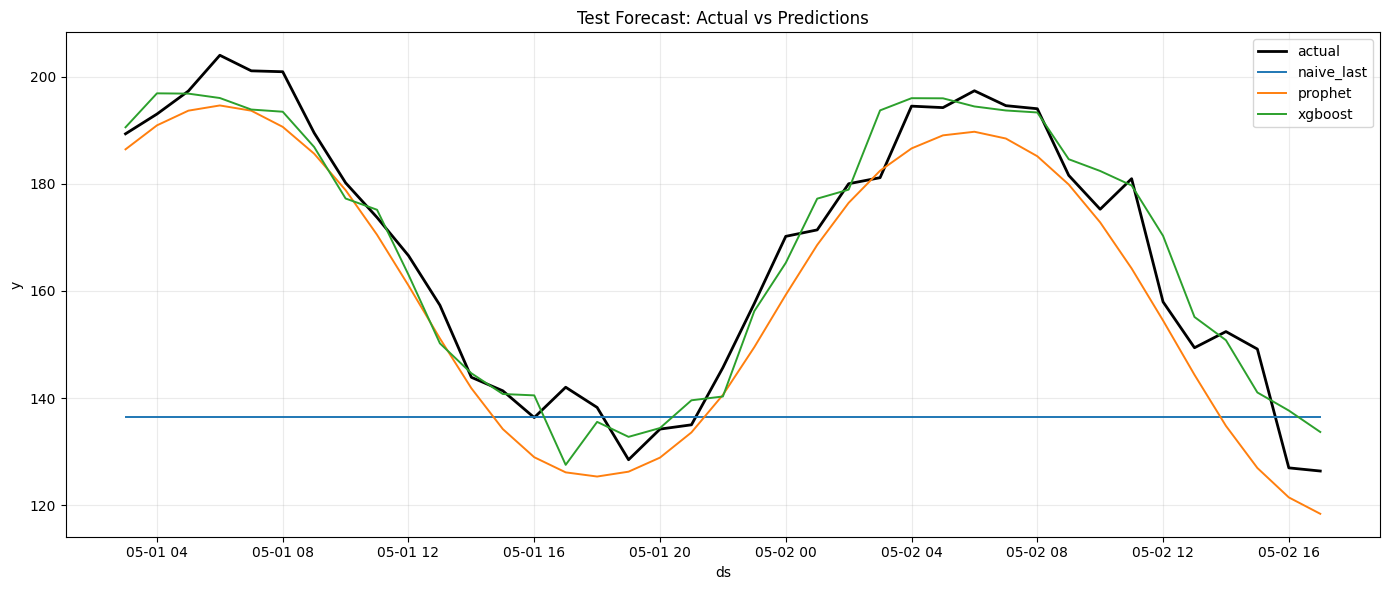

In [16]:
test_base = test_df[['ds', 'y']].copy().rename(columns={'y': 'actual'})
test_base['ds'] = pd.to_datetime(test_base['ds'], errors='coerce')

pred_tables: list[pd.DataFrame] = []

# naive_last on test
if not train_df.empty and not test_base.empty:
    last_value = float(train_df['y'].dropna().iloc[-1])
    naive_tbl = test_base[['ds']].copy()
    naive_tbl['naive_last'] = last_value
    pred_tables.append(naive_tbl)

# prophet on test
if prophet_result and prophet_result.get('status') == 'ok' and prophet_result.get('model_object') is not None:
    prophet_model = prophet_result['model_object']
    future = test_base[['ds']].copy()
    if getattr(future['ds'].dt, 'tz', None) is not None:
        future['ds'] = future['ds'].dt.tz_localize(None)
    prophet_fcst = prophet_model.predict(future)
    prophet_tbl = test_base[['ds']].copy()
    prophet_tbl['prophet'] = prophet_fcst['yhat'].to_numpy(dtype=float)
    pred_tables.append(prophet_tbl)

# xgboost on test (retrain on train+validation)
if xgb is not None and not train_df.empty and not val_df.empty and not test_df.empty:
    tv_df = pd.concat([train_df, val_df], ignore_index=True).sort_values('ds').reset_index(drop=True)
    all_df = pd.concat([train_df, val_df, test_df], ignore_index=True).sort_values('ds').reset_index(drop=True)

    tv_feat = build_xgb_frame(tv_df)
    all_feat = build_xgb_frame(all_df)
    test_start = pd.to_datetime(test_df['ds'].min(), errors='coerce')
    test_feat = all_feat[all_feat['ds'] >= test_start].copy()

    if not tv_feat.empty and not test_feat.empty:
        predictors = [c for c in tv_feat.columns if c not in {'ds', 'y'}]
        xgb_model = xgb.XGBRegressor(**(cfg.xgb_params or {}))
        xgb_model.fit(tv_feat[predictors], tv_feat['y'])
        xgb_pred = xgb_model.predict(test_feat[predictors]).astype(float)

        xgb_tbl = test_feat[['ds']].copy()
        xgb_tbl['xgboost'] = xgb_pred
        pred_tables.append(xgb_tbl)

# align by ds
viz_df = test_base.copy()
for tbl in pred_tables:
    viz_df = viz_df.merge(tbl, on='ds', how='left')

# metrics table
metric_rows: list[dict[str, Any]] = []
for model_col in ['naive_last', 'prophet', 'xgboost']:
    if model_col not in viz_df.columns:
        continue
    mask = viz_df['actual'].notna() & viz_df[model_col].notna()
    if int(mask.sum()) == 0:
        continue
    y_true = viz_df.loc[mask, 'actual'].to_numpy(dtype=float)
    y_pred = viz_df.loc[mask, model_col].to_numpy(dtype=float)
    metric_rows.append({
        'model': model_col,
        'points': int(mask.sum()),
        'mae': round(mae(y_true, y_pred), 4),
        'wape': round(wape(y_true, y_pred), 6),
        'rmse': round(rmse(y_true, y_pred), 4),
        'mape': round(mape(y_true, y_pred), 6),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values('mae', na_position='last').reset_index(drop=True)
display(metrics_df)

# chart
plt.figure(figsize=(14, 6))
plt.plot(viz_df['ds'], viz_df['actual'], label='actual', color='black', linewidth=2)
for model_col in ['naive_last', 'prophet', 'xgboost']:
    if model_col in viz_df.columns:
        plt.plot(viz_df['ds'], viz_df[model_col], label=model_col, linewidth=1.4)
plt.title('Test Forecast: Actual vs Predictions')
plt.xlabel('ds')
plt.ylabel('y')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Подготовка отчета

Отчет должен быть полезен и человеку, и последующему pipeline review. Минимум: summary по данным, comparison table, recommendation, список рисков и следующего шага.

In [18]:
def build_model_comparison(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for result in results:
        if not result or result.get('status') == 'skip':
            rows.append({
                'model_name': result.get('model_name') if result else 'unknown',
                'status': result.get('status') if result else 'missing',
                'fit_time_sec': result.get('fit_time_sec') if result else None,
                'mae': np.nan,
                'wape': np.nan,
                'mape': np.nan,
                'rmse': np.nan,
                'notes': result.get('notes', '') if result else '',
            })
            continue

        rows.append({
            'model_name': result['model_name'],
            'status': result['status'],
            'fit_time_sec': result.get('fit_time_sec'),
            'mae': result['metrics'].get('mae'),
            'wape': result['metrics'].get('wape'),
            'mape': result['metrics'].get('mape'),
            'rmse': result['metrics'].get('rmse'),
            'notes': result.get('notes', ''),
        })

    comparison = pd.DataFrame(rows)
    if 'mae' in comparison.columns:
        comparison = comparison.sort_values(by=['status', 'mae'], ascending=[True, True], na_position='last').reset_index(drop=True)
    return comparison


template_result = globals().get('template_result')
results = [baseline_result, prophet_result, xgb_result, template_result]
comparison_df = build_model_comparison([item for item in results if item is not None])
comparison_df

,model_name,status,fit_time_sec,mae,wape,mape,rmse,notes
0,prophet,ok,0.067,3.2129,0.021082,0.020935,4.0704,Prophet validation forecast
1,xgboost,ok,0.255,8.4046,0.055147,0.057039,9.9100,Predictors: 8
2,naive_last,ok,NaN,22.7107,0.149015,0.136459,29.2930,Repeats last observed value


In [19]:
def make_recommendation(comparison_df: pd.DataFrame, quality_df: pd.DataFrame, wape_warn_threshold: float = 1.0) -> dict[str, Any]:
    ready_rows = comparison_df[(comparison_df['status'] == 'ok') & comparison_df['mae'].notna()]
    best_model = ready_rows.sort_values('mae').iloc[0]['model_name'] if not ready_rows.empty else None

    warnings = quality_df[quality_df['status'] != 'ok']['check'].tolist() if not quality_df.empty else []
    reasons = []

    if best_model is not None:
        reasons.append(f'Lowest validation MAE among ready candidates: {best_model}')

        best_row = ready_rows[ready_rows['model_name'] == best_model].iloc[0]
        best_mae = float(best_row['mae']) if pd.notna(best_row.get('mae')) else float('nan')
        best_wape = float(best_row['wape']) if pd.notna(best_row.get('wape')) else float('nan')

        if not math.isnan(best_mae):
            reasons.append(f'Validation MAE for selected model: {best_mae:.4f}')
        if not math.isnan(best_wape):
            reasons.append(f'Validation WAPE for selected model: {best_wape:.6f}')
            if best_wape > wape_warn_threshold:
                warnings.append(f'wape_above_threshold({wape_warn_threshold})')

    if warnings:
        reasons.append('Data quality/performance warnings must be reviewed before publication')

    return {
        'recommended_model': best_model,
        'reasons': reasons,
        'data_warnings': warnings,
        'next_actions': [
            'Review data quality warnings',
            'Validate recommendation on recent holdout',
            'Publish artifact bundle and config if model is approved',
        ],
    }


recommendation = make_recommendation(comparison_df, quality_df)
recommendation

{'recommended_model': 'prophet',
 'reasons': ['Lowest validation MAE among ready candidates: prophet',
  'Validation MAE for selected model: 3.2129',
  'Validation WAPE for selected model: 0.021082',
  'Data quality/performance warnings must be reviewed before publication'],
 'data_warnings': ['min_sample_size'],
 'next_actions': ['Review data quality warnings',
  'Validate recommendation on recent holdout',
  'Publish artifact bundle and config if model is approved']}

## 13. Экспорт report bundle

Этот экспорт не заменяет MLflow logging, а создает human-readable companion artifacts для review и согласования.

In [20]:
def export_report_bundle(report_dir: Path, quality_df: pd.DataFrame, profile_df: pd.DataFrame, comparison_df: pd.DataFrame, recommendation: dict[str, Any]) -> dict[str, str]:
    report_dir.mkdir(parents=True, exist_ok=True)
    outputs = {
        'data_quality_summary': str(report_dir / 'data_quality_summary.csv'),
        'dataset_profile': str(report_dir / 'dataset_profile.csv'),
        'model_comparison': str(report_dir / 'model_comparison.csv'),
        'recommendation': str(report_dir / 'recommendation.json'),
    }

    quality_df.to_csv(outputs['data_quality_summary'], index=False)
    profile_df.to_csv(outputs['dataset_profile'], index=False)
    comparison_df.to_csv(outputs['model_comparison'], index=False)
    Path(outputs['recommendation']).write_text(json.dumps(recommendation, ensure_ascii=False, indent=2))
    return outputs


report_outputs = export_report_bundle(cfg.training_reports_dir, quality_df, profile_df, comparison_df, recommendation)
report_outputs

{'data_quality_summary': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/reports/data_quality_summary.csv',
 'dataset_profile': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/reports/dataset_profile.csv',
 'model_comparison': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/reports/model_comparison.csv',
 'recommendation': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/reports/recommendation.json'}

## 14. MLflow-compatible bundle and logging (prod)

Этот блок делает manual training "публикационно-готовым":

- формирует совместимый layout `bundle/model` + `bundle/configuration/cache_config.json`;
- сохраняет metadata и exported reports в `bundle/assets`;
- опционально логирует все это в MLflow run.

Включение режима: `cfg.mlflow_enabled = True`.

In [26]:
def compute_dataset_hash(df: pd.DataFrame) -> str:
    buf = io.BytesIO()
    df.to_parquet(buf, index=False)
    return hashlib.sha256(buf.getvalue()).hexdigest()


def _canonical_registry_model_name(config: TrainingNotebookConfig) -> str:
    # Stage 5 contract: registry name must be the pre-defined model id from object reference.
    return _sanitize_slug(str(config.object_reference))


def build_dataset_snapshot_files(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    assets_dir: Path,
) -> dict[str, str]:
    datasets_dir = assets_dir / 'datasets'
    datasets_dir.mkdir(parents=True, exist_ok=True)

    snapshots: dict[str, str] = {}
    for split_name, split_df in (('train', train_df), ('validation', val_df), ('test', test_df)):
        output_path = datasets_dir / f'{split_name}_snapshot.parquet'
        split_df.to_parquet(output_path, index=False)
        snapshots[f'{split_name}_snapshot'] = str(output_path)

    return snapshots


def build_runtime_cache_config(config: TrainingNotebookConfig, best_result: dict[str, Any] | None) -> dict[str, Any]:
    model_type = best_result.get('model_name') if best_result else 'unknown'
    return {
        'step': 3600,
        'input_range': None,
        'output_range': int(config.forecast_horizon),
        'clip_negatives_to_0': True,
        'use_dynamic_normalization': False,
        'model_type': str(model_type),
        'fallback': 'none',
        'archives': [],
        'historical_data_url': None,
        'historical_data_request_overrides': {},
        'weather_lat': None,
        'weather_lon': None,
        'weather_url': None,
        'weather_units': 'metric',
        'weather_hours': int(config.forecast_horizon),
        'cmms_url': None,
        'cmms_request_overrides': {},
    }


def _serialize_model_payload(model_name: str, model_object: Any, model_dir: Path) -> dict[str, Any]:
    model_dir.mkdir(parents=True, exist_ok=True)
    metadata: dict[str, Any] = {'model_name': model_name, 'saved': False, 'format': None, 'path': None, 'notes': ''}

    if model_object is None:
        metadata['notes'] = 'Model object is missing, serialization skipped'
        return metadata

    if model_name == 'xgboost' and hasattr(model_object, 'save_model'):
        output_path = model_dir / 'model.xgb.json'
        model_object.save_model(str(output_path))
        metadata.update({'saved': True, 'format': 'xgboost_json', 'path': str(output_path)})
        return metadata

    if model_name == 'prophet':
        try:
            from prophet.serialize import model_to_json
            output_path = model_dir / 'model.prophet.json'
            output_path.write_text(model_to_json(model_object))
            metadata.update({'saved': True, 'format': 'prophet_json', 'path': str(output_path)})
            return metadata
        except Exception as exc:
            metadata['notes'] = f'Prophet JSON serialization failed: {exc}'
            return metadata

    metadata['notes'] = f'Unsupported model_name for serializer: {model_name}'
    return metadata


def build_mlflow_compatible_bundle(
    config: TrainingNotebookConfig,
    comparison_df: pd.DataFrame,
    quality_df: pd.DataFrame,
    recommendation: dict[str, Any],
    report_outputs: dict[str, str],
    candidate_results: list[dict[str, Any]],
    raw_df: pd.DataFrame,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> dict[str, Any]:
    bundle_root = Path(config.bundle_output_dir)
    model_dir = bundle_root / 'bundle' / 'model'
    conf_dir = bundle_root / 'bundle' / 'configuration'
    assets_dir = bundle_root / 'bundle' / 'assets'

    if bundle_root.exists():
        shutil.rmtree(bundle_root)
    assets_dir.mkdir(parents=True, exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)
    conf_dir.mkdir(parents=True, exist_ok=True)

    selected_model_name = recommendation.get('recommended_model')
    selected_result = None
    for item in candidate_results:
        if item.get('model_name') == selected_model_name and item.get('status') == 'ok':
            selected_result = item
            break

    serializer_info = _serialize_model_payload(
        model_name=selected_model_name or 'unknown',
        model_object=None if selected_result is None else selected_result.get('model_object'),
        model_dir=model_dir,
    )

    cache_config = build_runtime_cache_config(config, selected_result)
    cache_config_path = conf_dir / 'cache_config.json'
    cache_config_path.write_text(json.dumps(cache_config, ensure_ascii=False, indent=2))

    snapshot_paths: dict[str, str] = {}
    if config.dataset_snapshot_enabled:
        snapshot_paths = build_dataset_snapshot_files(train_df, val_df, test_df, assets_dir)

    dataset_lineage = {
        'dataset_uri': str(config.dataset_path),
        'dataset_hash': compute_dataset_hash(raw_df),
        'row_count': int(len(raw_df)),
        'start_ts': str(raw_df['ds'].min()) if not raw_df.empty else None,
        'end_ts': str(raw_df['ds'].max()) if not raw_df.empty else None,
        'feature_schema_version': str(config.feature_schema_version),
        'snapshot_paths': snapshot_paths,
    }

    registry_model_name = _canonical_registry_model_name(config)
    manifest = {
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'object_reference': config.object_reference,
        'model_id': registry_model_name,
        'recommended_model': selected_model_name,
        'serializer': serializer_info,
        'metrics_table_rows': int(len(comparison_df)),
        'quality_checks_rows': int(len(quality_df)),
        'dataset_lineage': dataset_lineage,
        'storage': {
            'model_store_root': str(config.model_store_root),
            'model_home_dir': str(config.model_home_dir),
            'training_artifacts_dir': str(config.training_artifacts_dir),
            'runtime_cache_dir': str(config.runtime_cache_dir),
        },
    }
    manifest_path = assets_dir / 'manual_training_manifest.json'
    manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2))

    copied_reports: dict[str, str] = {}
    for key, report_path in report_outputs.items():
        src = Path(report_path)
        if src.exists():
            dst = assets_dir / src.name
            shutil.copy2(src, dst)
            copied_reports[key] = str(dst)

    return {
        'bundle_root': str(bundle_root),
        'registry_model_name': registry_model_name,
        'model_dir': str(model_dir),
        'cache_config_path': str(cache_config_path),
        'manifest_path': str(manifest_path),
        'copied_reports': copied_reports,
        'serializer': serializer_info,
        'dataset_lineage': dataset_lineage,
    }


def _register_best_model_and_alias(
    config: TrainingNotebookConfig,
    best_result: dict[str, Any] | None,
    run_id: str,
) -> dict[str, Any]:
    if best_result is None:
        return {
            'status': 'skipped',
            'reason': 'No best_result to register',
            'registered_model_name': _canonical_registry_model_name(config),
            'model_version': None,
            'model_alias': None,
        }

    model_name = str(best_result.get('model_name', ''))
    model_object = best_result.get('model_object')
    if model_object is None:
        return {
            'status': 'skipped',
            'reason': f'Model object is missing for {model_name}',
            'registered_model_name': _canonical_registry_model_name(config),
            'model_version': None,
            'model_alias': None,
        }

    import mlflow
    from mlflow.tracking import MlflowClient

    registered_model_name = _canonical_registry_model_name(config)

    if model_name == 'prophet':
        mlflow.prophet.log_model(
            pr_model=model_object,
            artifact_path='runtime_model',
            registered_model_name=registered_model_name,
        )
    elif model_name == 'xgboost':
        mlflow.xgboost.log_model(
            xgb_model=model_object,
            artifact_path='runtime_model',
            registered_model_name=registered_model_name,
        )
    else:
        return {
            'status': 'skipped',
            'reason': f'Unsupported model_name for MLflow registry registration: {model_name}',
            'registered_model_name': registered_model_name,
            'model_version': None,
            'model_alias': None,
        }

    client = MlflowClient(tracking_uri=config.mlflow_tracking_uri)
    selected_version = None
    for _ in range(8):
        versions = list(client.search_model_versions(f"name = '{registered_model_name}'"))
        run_versions = [v for v in versions if str(v.run_id) == str(run_id)]
        if run_versions:
            selected_version = max(run_versions, key=lambda v: int(v.version))
            break
        time.sleep(0.5)

    if selected_version is None:
        return {
            'status': 'failed',
            'reason': f'Cannot resolve model version for run_id={run_id}',
            'registered_model_name': registered_model_name,
            'model_version': None,
            'model_alias': None,
        }

    client.set_registered_model_alias(registered_model_name, 'Production', str(selected_version.version))
    return {
        'status': 'ok',
        'reason': '',
        'registered_model_name': registered_model_name,
        'model_version': str(selected_version.version),
        'model_alias': 'Production',
    }


def optional_log_bundle_to_mlflow(
    config: TrainingNotebookConfig,
    recommendation: dict[str, Any],
    best_result: dict[str, Any] | None,
    bundle_info: dict[str, Any],
) -> dict[str, Any]:
    if not config.mlflow_enabled:
        return {'status': 'skipped', 'reason': 'cfg.mlflow_enabled=False'}

    try:
        import mlflow
    except ImportError as exc:
        return {'status': 'skipped', 'reason': f'mlflow is not installed: {exc}'}

    if config.mlflow_tracking_uri:
        mlflow.set_tracking_uri(config.mlflow_tracking_uri)
    mlflow.set_experiment(config.mlflow_experiment_name)

    run_name = f"{config.mlflow_run_name_prefix}_{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}"

    with mlflow.start_run(run_name=run_name) as run:
        registry_model_name = _canonical_registry_model_name(config)
        mlflow.set_tag('object_reference', config.object_reference)
        mlflow.set_tag('model_id', registry_model_name)
        mlflow.set_tag('flow_type', 'manual_notebook')
        mlflow.set_tag('recommended_model', str(recommendation.get('recommended_model')))
        mlflow.set_tag('bundle_layout', 'bundle/model + bundle/configuration/cache_config.json')

        if best_result is not None:
            for key, value in (best_result.get('train_params') or {}).items():
                mlflow.log_param(f'train_params.{key}', value)
            for metric_name, metric_value in (best_result.get('metrics') or {}).items():
                if metric_value is not None and not (isinstance(metric_value, float) and math.isnan(metric_value)):
                    mlflow.log_metric(metric_name, float(metric_value))

        lineage = bundle_info.get('dataset_lineage') or {}
        if lineage:
            mlflow.set_tag('dataset_uri', str(lineage.get('dataset_uri')))
            mlflow.set_tag('dataset_hash', str(lineage.get('dataset_hash')))
            mlflow.log_param('row_count', int(lineage.get('row_count', 0)))
            mlflow.set_tag('start_ts', str(lineage.get('start_ts')))
            mlflow.set_tag('end_ts', str(lineage.get('end_ts')))
            mlflow.set_tag('feature_schema_version', str(lineage.get('feature_schema_version')))

        # Log only the inner local bundle directory to keep MLflow artifact layout as:
        # .../artifacts/bundle/configuration/cache_config.json
        local_bundle_dir = Path(bundle_info['bundle_root']) / 'bundle'
        mlflow.log_artifacts(str(local_bundle_dir), artifact_path='bundle')
        mlflow.log_artifacts(str(config.training_reports_dir), artifact_path='reports')

        registration_result = _register_best_model_and_alias(
            config=config,
            best_result=best_result,
            run_id=run.info.run_id,
        )

        artifact_warnings: list[str] = []
        if registration_result.get('status') != 'ok':
            artifact_warnings.append(str(registration_result.get('reason', 'model registration skipped')))

        return {
            'status': 'ok' if registration_result.get('status') != 'failed' else 'failed_partial',
            'run_id': run.info.run_id,
            'artifact_uri': run.info.artifact_uri,
            'tracking_uri': mlflow.get_tracking_uri(),
            'registered_model_name': registration_result.get('registered_model_name'),
            'model_version': registration_result.get('model_version'),
            'model_alias': registration_result.get('model_alias'),
            'artifact_warnings': artifact_warnings,
            'reason': registration_result.get('reason', ''),
        }

In [27]:
import mlflow
from mlflow.tracking import MlflowClient
from mlflow.entities import ViewType

template_result = globals().get('template_result')
candidate_results = [item for item in [baseline_result, prophet_result, xgb_result, template_result] if item is not None]
best_model_name = recommendation.get('recommended_model')
best_result = next((item for item in candidate_results if item.get('model_name') == best_model_name and item.get('status') == 'ok'), None)

bundle_info = build_mlflow_compatible_bundle(
    config=cfg,
    comparison_df=comparison_df,
    quality_df=quality_df,
    recommendation=recommendation,
    report_outputs=report_outputs,
    candidate_results=candidate_results,
    raw_df=raw_df,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
)

mlflow_result = None
try:
    mlflow_result = optional_log_bundle_to_mlflow(
        config=cfg,
        recommendation=recommendation,
        best_result=best_result,
        bundle_info=bundle_info,
    )
except Exception as exc:
    # Recovery for: "Cannot set a deleted experiment ... as the active experiment"
    if cfg.mlflow_enabled and 'Cannot set a deleted experiment' in str(exc):
        try:
            if cfg.mlflow_tracking_uri:
                mlflow.set_tracking_uri(cfg.mlflow_tracking_uri)

            client = MlflowClient(tracking_uri=cfg.mlflow_tracking_uri)
            exp_name = cfg.mlflow_experiment_name

            deleted_exp = next(
                (e for e in client.search_experiments(view_type=ViewType.DELETED_ONLY) if e.name == exp_name),
                None,
            )
            if deleted_exp is not None:
                client.restore_experiment(deleted_exp.experiment_id)

            mlflow_result = optional_log_bundle_to_mlflow(
                config=cfg,
                recommendation=recommendation,
                best_result=best_result,
                bundle_info=bundle_info,
            )
        except Exception as restore_exc:
            mlflow_result = {
                'status': 'failed',
                'reason': f'{type(restore_exc).__name__}: {restore_exc}',
                'bundle_saved': bool(bundle_info),
                'local_bundle_root': str(bundle_info.get('bundle_root', '')),
            }
    else:
        mlflow_result = {
            'status': 'failed',
            'reason': f'{type(exc).__name__}: {exc}',
            'bundle_saved': bool(bundle_info),
            'local_bundle_root': str(bundle_info.get('bundle_root', '')),
        }

{
    'registry_model_name': bundle_info.get('registry_model_name'),
    'bundle_info': bundle_info,
    'mlflow_result': mlflow_result,
}

2026/05/11 08:37:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt'.
2026/05/11 08:37:02 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt, version 1


🏃 View run manual_training_20260511_033701 at: http://127.0.0.1:5050/#/experiments/4/runs/b321a9e628f540a68f6e99fdab34c535
🧪 View experiment at: http://127.0.0.1:5050/#/experiments/4


Created version '1' of model 'root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt'.


{'registry_model_name': 'root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt',
 'bundle_info': {'bundle_root': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/bundle_export',
  'registry_model_name': 'root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt',
  'model_dir': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/bundle_export/bundle/model',
  'cache_config_path': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/bundle_export/bundle/configuration/cache_config.json',
  'manifest_path': '/Users/rustamkrikbayev/Documents/projects/forecast/local/models/root_FP_PROJECT_AKMOLA_regions_North_Kazakhstan_load_models_P_watt_h36/training/bundle_export/bundle/assets/manual_trainin

In [28]:
from mlflow.tracking import MlflowClient as _MlflowClient


def _find_local_run_dir(mlruns_root: Path, run_id: str) -> Path | None:
    for exp_dir in mlruns_root.iterdir():
        if not exp_dir.is_dir() or exp_dir.name == 'manual_reg':
            continue
        candidate = exp_dir / run_id
        if candidate.exists():
            return candidate
    return None


def _offline_training_status(model_home_dir: Path) -> tuple[str, dict[str, bool]]:
    training_root = model_home_dir / 'training'
    report_ok = (training_root / 'reports' / 'recommendation.json').exists()
    manifest_ok = (training_root / 'bundle_export' / 'bundle' / 'assets' / 'manual_training_manifest.json').exists()
    cache_cfg_ok = (training_root / 'bundle_export' / 'bundle' / 'configuration' / 'cache_config.json').exists()

    checks = {
        'report_ok': report_ok,
        'manifest_ok': manifest_ok,
        'cache_config_ok': cache_cfg_ok,
    }
    ok_count = sum(int(v) for v in checks.values())
    if ok_count == 3:
        return 'trained', checks
    if ok_count > 0:
        return 'partial', checks
    return 'missing', checks


def _candidate_registry_model_names(object_ref: str, output_range: int | None) -> list[str]:
    base = _sanitize_slug(object_ref)
    candidates = [
        base,
        f'{base}_h{int(output_range)}' if output_range is not None else '',
        f'{base}_h24',
        f'{base}_model',
        f'{base}_h{int(output_range)}_model' if output_range is not None else '',
        f'{base}_h24_model',
    ]
    result: list[str] = []
    for name in candidates:
        if name and name not in result:
            result.append(name)
    return result


def _resolve_existing_model_home_dir(config: TrainingNotebookConfig, object_ref: str, output_range: int | None) -> Path:
    base = _sanitize_slug(object_ref)
    candidate_names = [
        base,
        f'{base}_h{int(output_range)}' if output_range is not None else '',
        f'{base}_h24',
    ]
    for candidate_name in candidate_names:
        if not candidate_name:
            continue
        candidate_dir = Path(config.model_store_root) / candidate_name
        if candidate_dir.exists():
            return candidate_dir
    return Path(config.model_store_root) / base


def _production_alias_info(client: _MlflowClient | None, model_name_candidates: list[str]) -> dict[str, Any]:
    if client is None:
        return {
            'alias_status': 'unknown',
            'run_id': None,
            'model_version': None,
            'alias': None,
            'reason': 'registry_unavailable',
            'model_id': model_name_candidates[0] if model_name_candidates else None,
        }

    last_error = ''
    for model_id in model_name_candidates:
        try:
            mv = client.get_model_version_by_alias(model_id, 'Production')
            return {
                'alias_status': 'present',
                'run_id': str(mv.run_id),
                'model_version': str(mv.version),
                'alias': 'Production',
                'reason': '',
                'model_id': model_id,
            }
        except Exception as exc:
            last_error = str(exc)

    return {
        'alias_status': 'missing',
        'run_id': None,
        'model_version': None,
        'alias': None,
        'reason': last_error,
        'model_id': model_name_candidates[0] if model_name_candidates else None,
    }


def _resolve_logged_cache_config_path(run_dir: Path | None) -> Path | None:
    if run_dir is None:
        return None
    candidate = run_dir / 'artifacts' / 'bundle' / 'configuration' / 'cache_config.json'
    if candidate.exists():
        return candidate
    return None


def build_reconciliation_audit_df(config: TrainingNotebookConfig) -> pd.DataFrame:
    # Read candidate list from batch_summary.json (only source of truth)
    summary_path = Path(config.model_store_root) / 'batch_summary.json'
    if not summary_path.exists():
        return pd.DataFrame(columns=[
            'object_ref', 'model_id', 'data_collection_status', 'data_collection_reason',
            'offline_training_status', 'prod_cache_status', 'lifecycle_status',
            'production_alias', 'model_version', 'run_id', 'local_run_dir',
            'offline_report_ok', 'offline_manifest_ok', 'offline_cache_config_ok', 'mismatch_flag',
        ])

    _summary_list = json.loads(summary_path.read_text(encoding='utf-8'))

    mlruns_root = Path(config.model_store_root).parent / 'mlruns'
    mlruns_root.mkdir(parents=True, exist_ok=True)

    client: _MlflowClient | None = None
    try:
        client = _MlflowClient(tracking_uri=config.mlflow_tracking_uri) if config.mlflow_tracking_uri else None
    except Exception:
        client = None

    rows: list[dict[str, Any]] = []
    for _s in _summary_list:
        object_ref = str(_s.get('object_ref', ''))
        output_range = int(_s.get('output_range', 24)) if str(_s.get('output_range', '')).strip() else 24

        model_name_candidates = _candidate_registry_model_names(object_ref, output_range)
        alias_info = _production_alias_info(client, model_name_candidates)
        model_id = str(alias_info.get('model_id') or model_name_candidates[0])

        model_home_dir = _resolve_existing_model_home_dir(config, object_ref, output_range)
        offline_status, offline_checks = _offline_training_status(model_home_dir)

        run_id = alias_info.get('run_id')
        run_dir = _find_local_run_dir(mlruns_root, str(run_id)) if run_id else None
        local_bundle_cfg = _resolve_logged_cache_config_path(run_dir)

        if alias_info['alias_status'] == 'present' and local_bundle_cfg is not None:
            prod_cache_status = 'present'
        elif alias_info['alias_status'] == 'present' and run_dir is not None:
            prod_cache_status = 'partial'
        elif alias_info['alias_status'] == 'present':
            prod_cache_status = 'missing_local'
        elif alias_info['alias_status'] == 'missing':
            prod_cache_status = 'missing'
        else:
            prod_cache_status = 'unknown'

        mismatch_flag = (
            (offline_status in {'trained', 'partial'} and prod_cache_status in {'missing', 'missing_local'})
            or (offline_status == 'missing' and prod_cache_status == 'present')
        )

        if offline_status == 'trained' and prod_cache_status == 'present':
            lifecycle_status = 'serving_ready'
        elif offline_status in {'trained', 'partial'} and prod_cache_status in {'missing', 'missing_local'}:
            lifecycle_status = 'trained_only'
        elif offline_status == 'missing' and prod_cache_status == 'present':
            lifecycle_status = 'cache_without_offline'
        elif prod_cache_status == 'partial' or offline_status == 'partial':
            lifecycle_status = 'cache_partial'
        else:
            lifecycle_status = 'missing'

        rows.append({
            'object_ref': object_ref,
            'model_id': model_id,
            'data_collection_status': str(_s.get('status', 'unknown')),
            'data_collection_reason': str(_s.get('reason', '')),
            'offline_training_status': offline_status,
            'prod_cache_status': prod_cache_status,
            'lifecycle_status': lifecycle_status,
            'production_alias': alias_info.get('alias'),
            'model_version': alias_info.get('model_version'),
            'run_id': run_id,
            'local_run_dir': '' if run_dir is None else str(run_dir),
            'offline_report_ok': offline_checks['report_ok'],
            'offline_manifest_ok': offline_checks['manifest_ok'],
            'offline_cache_config_ok': offline_checks['cache_config_ok'],
            'mismatch_flag': mismatch_flag,
        })

    audit_df = pd.DataFrame(rows)
    if not audit_df.empty:
        audit_df = audit_df.sort_values(['mismatch_flag', 'lifecycle_status', 'object_ref'], ascending=[False, True, True]).reset_index(drop=True)
    return audit_df


audit_df = build_reconciliation_audit_df(cfg)
summary_df = (
    audit_df.groupby('lifecycle_status', dropna=False)['model_id']
    .count()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
    if not audit_df.empty else pd.DataFrame(columns=['lifecycle_status', 'count'])
)

print(f'total_models={len(audit_df)}')
print(f'mismatches={int(audit_df["mismatch_flag"].sum()) if not audit_df.empty else 0}')
display(summary_df)
display(audit_df.head(50))

total_models=3
mismatches=1


,lifecycle_status,count
0,cache_partial,1
1,cache_without_offline,1
2,missing,1


,object_ref,model_id,data_collection_status,data_collection_reason,offline_training_status,prod_cache_status,lifecycle_status,production_alias,model_version,run_id,local_run_dir,offline_report_ok,offline_manifest_ok,offline_cache_config_ok,mismatch_flag
0,/root/FP/PROJECT/AKMOLA/@regions/North Kazakhs...,root_FP_PROJECT_AKMOLA_regions_North_Kazakhsta...,ok,,missing,present,cache_without_offline,Production,1,b321a9e628f540a68f6e99fdab34c535,/Users/rustamkrikbayev/Documents/projects/fore...,False,False,False,True
1,/root/FP/PROJECT/AKMOLA/VostVet_VES/@models/P_...,root_FP_PROJECT_AKMOLA_VostVet_VES_models_P_wa...,ok,,missing,partial,cache_partial,Production,3,80715963686c46bdb820f5c77f160518,/Users/rustamkrikbayev/Documents/projects/fore...,False,False,False,False
2,/root/FP/PROJECT/AKMOLA/@regions/Kokshetau/loa...,root_FP_PROJECT_AKMOLA_regions_Kokshetau_load_...,ok,,missing,missing,missing,None,None,None,,False,False,False,False


## 15. Reconciliation audit: offline training vs prod cache (prod)

Этот блок строит единую матрицу по `model_id` и показывает расхождения между двумя контурами:
- offline/manual training artifacts в `local/models/<model_id>/training`;
- prod cache публикации в `local/mlruns` + alias `Production` в MLflow Registry.

Цель: быстро увидеть `trained_only`, `serving_ready`, `cache_partial`, `missing`.

## 16. Итог

После прохождения notebook у вас должны быть:

**Single-model workflow (секции 1–15):**
- подтвержденный quality snapshot по данным;
- comparison table по model candidates (naive_last, prophet, xgboost);
- recommendation по выбору алгоритма;
- exportable report bundle для review;
- MLflow run с совместимым `bundle/model` + `bundle/configuration/cache_config.json` и alias `Production`.

**Batch training wave (секция 16):**
- eligibility check: список моделей со `status=ok`, исключая уже обученные (alias `Production`);
- последовательный batch-run: одна модель = один training pipeline + MLflow registration;
- wave report в `manual_reports/wave_reports/wave_YYYYMMDD_HHMMSS.json` с балансом trained / skipped / failed;
- reconciliation audit (секция 15) для подтверждения роста `serving_ready` после волны.

**Переобучение конкретной модели:**
- установить `RETRAIN_MODEL_ID = 'model_id'` в ячейке 16.3 и запустить только её;
- batch-проход при этом не выполняется.

Если `cfg.mlflow_enabled=False`, notebook формирует bundle локально и позволяет выполнить публикацию позже.